# Supply Chain Analytics Project

## Project Overview

This comprehensive Supply Chain Analytics project demonstrates end-to-end data analysis capabilities including:
- **Data Collection**: Real-world data from World Bank + Synthetic operational data
- **Data Cleaning & Preprocessing**: Handling missing values, outliers, and data transformation
- **Exploratory Data Analysis (EDA)**: Understanding patterns and trends
- **Key Performance Indicators (KPIs)**: Supply chain metrics and performance measurement
- **Visualizations & Dashboards**: Interactive and static visualizations
- **Insights & Recommendations**: Data-driven business insights

---

## Table of Contents

1. [Import Libraries & Setup](#1-import-libraries--setup)
2. [Data Collection](#2-data-collection)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
5. [Supply Chain KPIs Analysis](#5-supply-chain-kpis-analysis)
6. [Advanced Analytics](#6-advanced-analytics)
7. [Visualizations & Dashboards](#7-visualizations--dashboards)
8. [Insights & Recommendations](#8-insights--recommendations)

---

## Data Sources

### 1. World Bank Open Data (Real-world Data)
- **Source**: [World Bank Open Data](https://data.worldbank.org/)
- **Indicators**: Logistics Performance Index, Trade Statistics, Lead Times, Customs Efficiency
- **Countries**: USA, China, Germany, Japan, UK, France, India, Korea, Brazil, Mexico
- **Time Period**: 2017-2024

### 2. Synthetic Supply Chain Operations Data
- **Orders**: 5,000 transaction records
- **Products**: 50 products across 6 categories
- **Suppliers**: 20 suppliers from 7 countries
- **Warehouses**: 8 warehouses across 5 regions
- **Customers**: 300 customers in different segments
- **Time Period**: 2022-2023

---

## 1. Import Libraries & Setup

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualizations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

# Date & Time
from datetime import datetime, timedelta

# Statistical Analysis
from scipy import stats
from scipy.stats import norm

# Machine Learning (for forecasting)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ All libraries imported successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Analysis Date: 2026-03-09 01:10:59


---

## 2. Data Collection

### 2.1 Load World Bank Logistics Data

In [2]:
# Load World Bank logistics data
wb_data = pd.read_csv('data/world_bank_logistics_data.csv')

print("World Bank Logistics Data:")
print(f"Shape: {wb_data.shape}")
print("\nColumn Names:")
print(wb_data.columns.tolist())
print("\nFirst 5 rows:")
wb_data.head()

World Bank Logistics Data:
Shape: (452, 5)

Column Names:
['indicator', 'country', 'date', 'unit', 'value']

First 5 rows:


,indicator,country,date,unit,value
0,LP.LPI.TRAC.XQ,United States(US),2022,NaN,4.20
1,LP.LPI.TRAC.XQ,United States(US),2018,NaN,4.09
2,LP.LPI.LOGS.XQ,United States(US),2022,NaN,3.90
3,LP.LPI.LOGS.XQ,United States(US),2018,NaN,3.87
4,LP.LPI.CUST.XQ,United States(US),2022,NaN,3.70


In [3]:
# Understand the indicators
indicator_mapping = {
    'LP.LPI.TRAC.XQ': 'Logistics Performance: Track & Trace',
    'LP.LPI.LOGS.XQ': 'Logistics Performance: Service Quality',
    'LP.LPI.CUST.XQ': 'Logistics Performance: Customs Efficiency',
    'LP.EXP.DURS.MD': 'Lead Time to Export (days)',
    'LP.IMP.DURS.MD': 'Lead Time to Import (days)',
    'IC.CUS.DURS.EX': 'Customs Clearance Time (days)',
    'NE.TRD.GNFS.ZS': 'Trade (% of GDP)',
    'BX.GSR.MRCH.CD': 'Goods Exports (USD)',
    'BM.GSR.MRCH.CD': 'Goods Imports (USD)',
    'NV.IND.MANF.ZS': 'Manufacturing (% of GDP)',
    'IS.SHP.GCNW.XQ': 'Shipping Connectivity Index'
}

# Add indicator description
wb_data['Indicator_Name'] = wb_data['indicator'].map(indicator_mapping)

print("Indicator Summary:")
for code, name in indicator_mapping.items():
    count = wb_data[wb_data['indicator'] == code].shape[0]
    print(f"  {code}: {name} ({count} records)")

Indicator Summary:
  LP.LPI.TRAC.XQ: Logistics Performance: Track & Trace (20 records)
  LP.LPI.LOGS.XQ: Logistics Performance: Service Quality (20 records)
  LP.LPI.CUST.XQ: Logistics Performance: Customs Efficiency (20 records)
  LP.EXP.DURS.MD: Lead Time to Export (days) (9 records)
  LP.IMP.DURS.MD: Lead Time to Import (days) (9 records)
  IC.CUS.DURS.EX: Customs Clearance Time (days) (8 records)
  NE.TRD.GNFS.ZS: Trade (% of GDP) (80 records)
  BX.GSR.MRCH.CD: Goods Exports (USD) (80 records)
  BM.GSR.MRCH.CD: Goods Imports (USD) (80 records)
  NV.IND.MANF.ZS: Manufacturing (% of GDP) (76 records)
  IS.SHP.GCNW.XQ: Shipping Connectivity Index (50 records)


### 2.2 Load Supply Chain Operations Data

In [4]:
# Load all supply chain datasets
orders = pd.read_csv('data/orders.csv', parse_dates=[
    'Order_Date', 'Ship_Date', 'Expected_Delivery', 'Actual_Delivery'
])
products = pd.read_csv('data/products.csv')
suppliers = pd.read_csv('data/suppliers.csv')
warehouses = pd.read_csv('data/warehouses.csv')
customers = pd.read_csv('data/customers.csv')

print("Supply Chain Operations Data Loaded:")
print(f"  📦 Orders: {orders.shape}")
print(f"  🏷️ Products: {products.shape}")
print(f"  🏭 Suppliers: {suppliers.shape}")
print(f"  🏢 Warehouses: {warehouses.shape}")
print(f"  👥 Customers: {customers.shape}")

Supply Chain Operations Data Loaded:
  📦 Orders: (5000, 32)
  🏷️ Products: (50, 6)
  🏭 Suppliers: (20, 6)
  🏢 Warehouses: (8, 5)
  👥 Customers: (300, 5)


In [5]:
# Display sample data from each dataset
print("\n=== ORDERS SAMPLE ===")
print(orders[['Order_ID', 'Order_Date', 'Product_Name', 'Category', 'Total_Amount', 
              'Order_Status', 'Shipping_Mode']].head())

print("\n=== PRODUCTS SAMPLE ===")
print(products.head())

print("\n=== SUPPLIERS SAMPLE ===")
print(suppliers.head())


=== ORDERS SAMPLE ===
     Order_ID Order_Date Product_Name         Category  Total_Amount  \
0  ORD_000001 2023-08-17   Product_11    Home & Garden       6653.10   
1  ORD_000002 2023-07-08   Product_10           Sports       1612.96   
2  ORD_000003 2023-04-11   Product_48    Home & Garden       1841.84   
3  ORD_000004 2023-06-08   Product_22      Electronics      16150.00   
4  ORD_000005 2022-03-14   Product_37  Health & Beauty      11191.95   

  Order_Status Shipping_Mode  
0    Delivered           Sea  
1    Delivered          Road  
2    Cancelled          Road  
3    Delivered           Sea  
4    Delivered           Air  

=== PRODUCTS SAMPLE ===
  Product_ID Product_Name         Category  Unit_Price  Weight_kg Supplier_ID
0   PROD_001    Product_1    Home & Garden      286.01      33.48     SUP_009
1   PROD_002    Product_2           Sports      198.85      33.33     SUP_020
2   PROD_003    Product_3  Food & Beverage       17.82      29.61     SUP_017
3   PROD_004    Produ

---

## 3. Data Cleaning & Preprocessing

### 3.1 World Bank Data Cleaning

In [6]:
# Check for missing values
print("Missing Values in World Bank Data:")
print(wb_data.isnull().sum())

# Remove rows with missing values
wb_clean = wb_data.dropna().copy()

# Convert value column to numeric
wb_clean['value'] = pd.to_numeric(wb_clean['value'], errors='coerce')

# Pivot the data for easier analysis
wb_pivot = wb_clean.pivot_table(
    index=['country', 'date'],
    columns='Indicator_Name',
    values='value',
    aggfunc='first'
).reset_index()

print(f"\nPivoted Data Shape: {wb_pivot.shape}")
print("\nColumns:")
print(wb_pivot.columns.tolist())
wb_pivot.head()

Missing Values in World Bank Data:
indicator           0
country             0
date                0
unit              452
value               0
Indicator_Name      0
dtype: int64

Pivoted Data Shape: (0, 2)

Columns:
['country', 'date']


Indicator_Name,country,date


### 3.2 Orders Data Cleaning

In [7]:
# Check data types
print("Data Types:")
print(orders.dtypes)

# Check for missing values
print("\n=== MISSING VALUES ===")
missing = orders.isnull().sum()
missing_pct = (missing / len(orders)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Check for duplicates
print(f"\nDuplicate Orders: {orders.duplicated().sum()}")

Data Types:
Order_ID                        object
Order_Date              datetime64[ns]
Product_ID                      object
Product_Name                    object
Category                        object
Supplier_ID                     object
Supplier_Name                   object
Supplier_Country                object
Warehouse_ID                    object
Customer_ID                     object
Customer_Region                 object
Customer_Segment                object
Quantity                         int64
Unit_Price                     float64
Total_Amount                   float64
Shipping_Mode                   object
Shipping_Cost                  float64
Order_Status                    object
Order_Date_Timestamp            object
Ship_Date               datetime64[ns]
Expected_Delivery       datetime64[ns]
Actual_Delivery         datetime64[ns]
Lead_Time_Days                   int64
Actual_Lead_Time               float64
Delay_Days                     float64
Inventory_Lev

In [8]:
# Handle missing values appropriately
orders_clean = orders.copy()

# For delivered orders, fill missing delay days with 0
orders_clean.loc[orders_clean['Order_Status'] == 'Delivered', 'Delay_Days'] = \
    orders_clean.loc[orders_clean['Order_Status'] == 'Delivered', 'Delay_Days'].fillna(0)

# Create derived features
orders_clean['Year_Month'] = orders_clean['Order_Date'].dt.to_period('M')
orders_clean['Is_Delayed'] = orders_clean['Delay_Days'].fillna(0) > 0
orders_clean['Total_Cost'] = orders_clean['Total_Amount'] + orders_clean['Shipping_Cost']

# Calculate inventory status
orders_clean['Inventory_Status'] = orders_clean.apply(
    lambda x: 'Low Stock' if x['Inventory_Level'] < x['Reorder_Point'] else 'Normal', axis=1
)

print("✅ Data cleaning completed!")
print(f"Final dataset shape: {orders_clean.shape}")

✅ Data cleaning completed!
Final dataset shape: (5000, 36)


### 3.3 Outlier Detection & Treatment

In [9]:
# Detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in key metrics
numeric_cols = ['Total_Amount', 'Shipping_Cost', 'Quantity', 'Lead_Time_Days']

print("Outlier Analysis:")
for col in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(orders_clean, col)
    print(f"\n{col}:")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(orders_clean)*100:.2f}%)")
    print(f"  Range: {lb:.2f} to {ub:.2f}")
    print(f"  Actual Range: {orders_clean[col].min():.2f} to {orders_clean[col].max():.2f}")

Outlier Analysis:

Total_Amount:
  Outliers: 75 (1.50%)
  Range: -18827.90 to 41507.84
  Actual Range: 17.82 to 47815.02

Shipping_Cost:
  Outliers: 330 (6.60%)
  Range: -4458.34 to 9444.23
  Actual Range: 0.16 to 43897.37

Quantity:
  Outliers: 0 (0.00%)
  Range: -50.00 to 150.00
  Actual Range: 1.00 to 99.00

Lead_Time_Days:
  Outliers: 0 (0.00%)
  Range: -5.50 to 70.50
  Actual Range: 4.00 to 66.00


---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Global Logistics Performance Analysis

In [10]:
# Analyze Logistics Performance Index by Country
lpi_cols = [col for col in wb_pivot.columns if 'Logistics Performance' in col]

if lpi_cols:
    # Get most recent data
    latest_year = wb_pivot['date'].max()
    latest_data = wb_pivot[wb_pivot['date'] == latest_year]
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, col in enumerate(lpi_cols[:3]):
        if col in latest_data.columns:
            data = latest_data.dropna(subset=[col]).sort_values(col, ascending=True)
            axes[idx].barh(data['country'], data[col], color=plt.cm.viridis(np.linspace(0, 1, len(data))))
            axes[idx].set_xlabel('Score (1=Low to 5=High)')
            axes[idx].set_title(f'{col}\n({latest_year})')
            axes[idx].set_xlim(0, 5)
    
    plt.tight_layout()
    plt.savefig('images/logistics_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n📊 Data from year: {latest_year}")

In [11]:
# Trade statistics analysis
trade_cols = ['Goods Exports (USD)', 'Goods Imports (USD)', 'Trade (% of GDP)']
available_trade_cols = [col for col in trade_cols if col in wb_pivot.columns]

if available_trade_cols:
    # Get latest year data
    latest_year = wb_pivot['date'].max()
    trade_data = wb_pivot[wb_pivot['date'] == latest_year][['country'] + available_trade_cols].copy()
    
    # Convert to billions for readability
    if 'Goods Exports (USD)' in trade_data.columns:
        trade_data['Exports (B USD)'] = trade_data['Goods Exports (USD)'] / 1e9
    if 'Goods Imports (USD)' in trade_data.columns:
        trade_data['Imports (B USD)'] = trade_data['Goods Imports (USD)'] / 1e9
    
    # Create trade balance visualization
    if 'Exports (B USD)' in trade_data.columns and 'Imports (B USD)' in trade_data.columns:
        trade_data['Trade Balance'] = trade_data['Exports (B USD)'] - trade_data['Imports (B USD)']
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Exports vs Imports
        countries = trade_data['country'].values
        x = np.arange(len(countries))
        width = 0.35
        
        axes[0].bar(x - width/2, trade_data['Exports (B USD)'], width, label='Exports', color='#2ecc71')
        axes[0].bar(x + width/2, trade_data['Imports (B USD)'], width, label='Imports', color='#e74c3c')
        axes[0].set_xlabel('Country')
        axes[0].set_ylabel('Value (Billion USD)')
        axes[0].set_title(f'Exports vs Imports by Country ({latest_year})')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(countries, rotation=45, ha='right')
        axes[0].legend()
        
        # Trade Balance
        colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in trade_data['Trade Balance']]
        axes[1].bar(countries, trade_data['Trade Balance'], color=colors)
        axes[1].set_xlabel('Country')
        axes[1].set_ylabel('Trade Balance (Billion USD)')
        axes[1].set_title(f'Trade Balance by Country ({latest_year})')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        plt.tight_layout()
        plt.savefig('images/trade_statistics.png', dpi=300, bbox_inches='tight')
        plt.show()

### 4.2 Orders Analysis

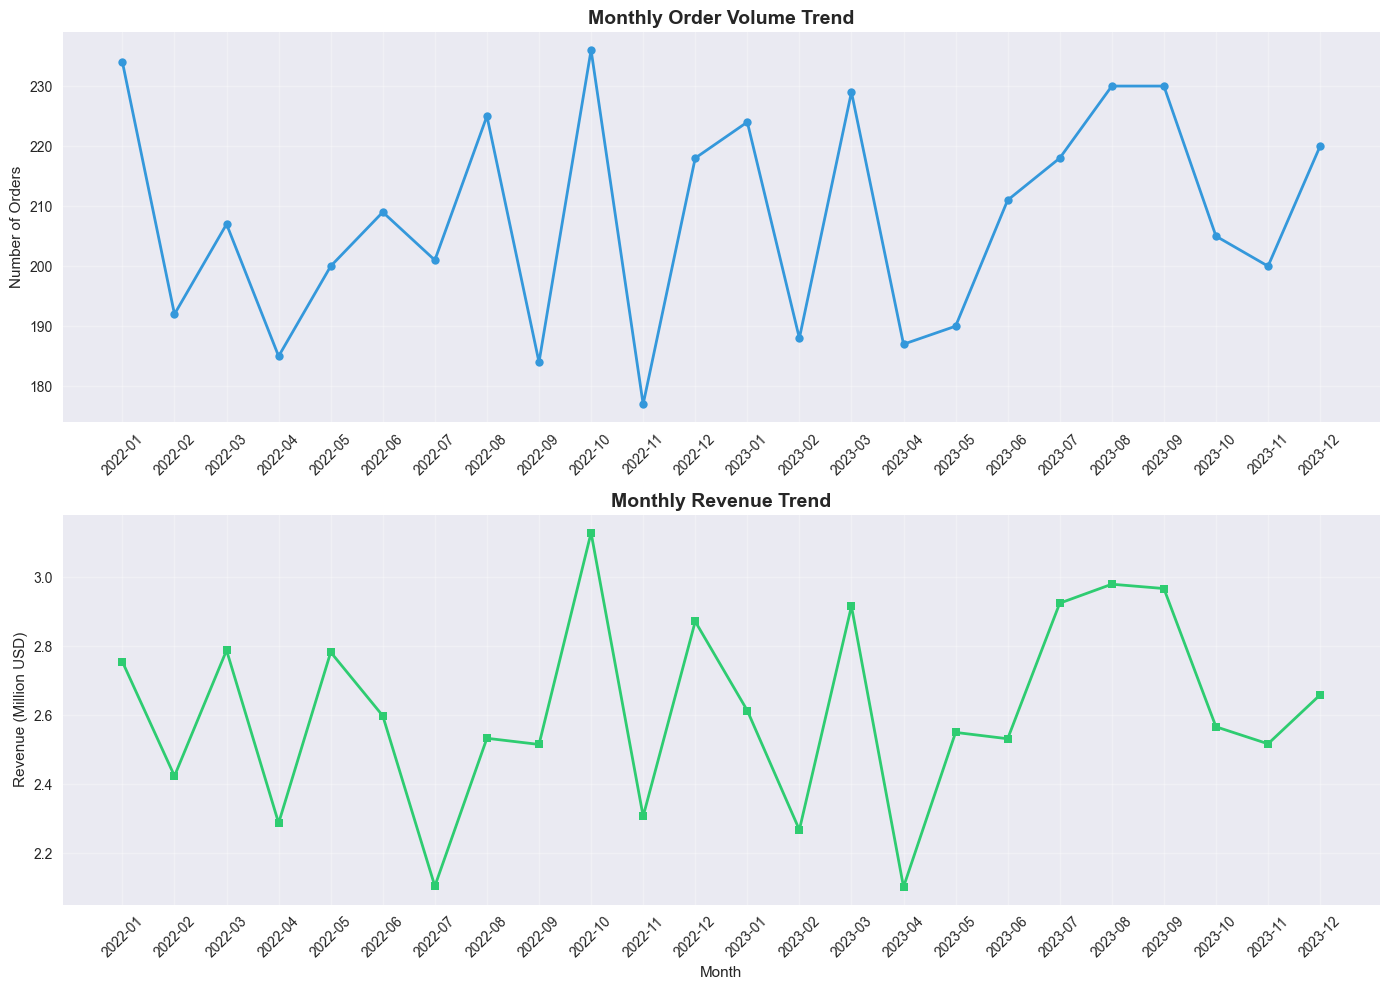

In [12]:
# Order trends over time
monthly_orders = orders_clean.groupby('Year_Month').agg({
    'Order_ID': 'count',
    'Total_Amount': 'sum',
    'Total_Cost': 'sum'
}).reset_index()
monthly_orders['Year_Month'] = monthly_orders['Year_Month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Order volume trend
axes[0].plot(monthly_orders['Year_Month'], monthly_orders['Order_ID'], 
             marker='o', linewidth=2, markersize=6, color='#3498db')
axes[0].set_title('Monthly Order Volume Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Revenue trend
axes[1].plot(monthly_orders['Year_Month'], monthly_orders['Total_Amount']/1e6, 
             marker='s', linewidth=2, markersize=6, color='#2ecc71')
axes[1].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue (Million USD)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/order_trends.png', dpi=300, bbox_inches='tight')
plt.show()

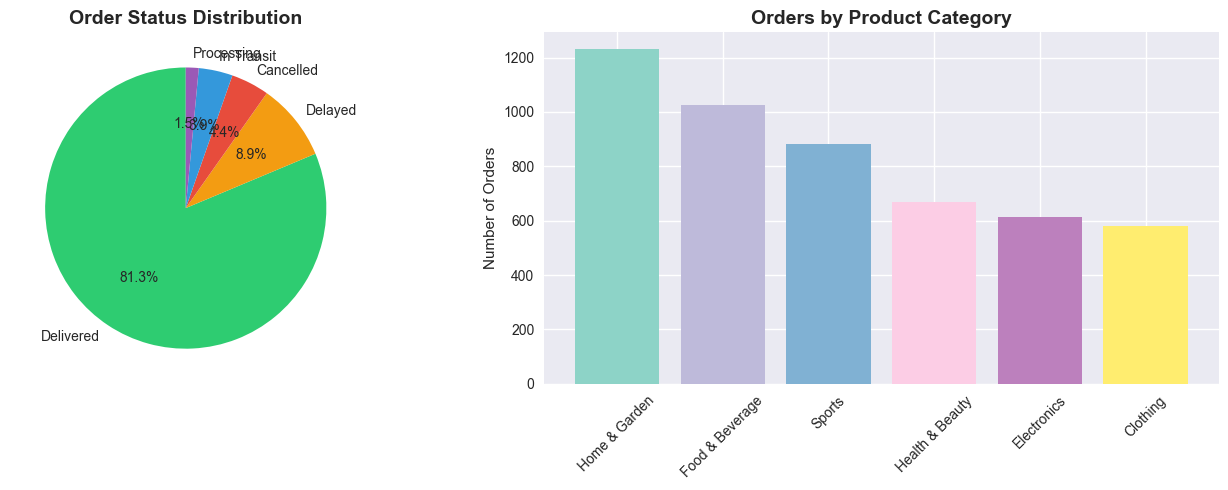

In [13]:
# Order status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Status pie chart
status_counts = orders_clean['Order_Status'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6']
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Order Status Distribution', fontsize=14, fontweight='bold')

# Category distribution
category_orders = orders_clean['Category'].value_counts()
axes[1].bar(category_orders.index, category_orders.values, color=plt.cm.Set3(np.linspace(0, 1, len(category_orders))))
axes[1].set_title('Orders by Product Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/order_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Shipping & Logistics Analysis

Shipping Mode Analysis:
  Shipping_Mode  Order_Count  Avg_Shipping_Cost  Total_Shipping_Cost  \
0           Air          733            7061.02           5175730.38   
1          Rail          517            2432.28           1257489.28   
2          Road         2023            3086.50           6243980.04   
3           Sea         1727            2120.42           3661968.03   

   Avg_Lead_Time  On_Time_Rate  
0          23.74          0.75  
1          31.80          0.74  
2          26.65          0.75  
3          42.45          0.74  


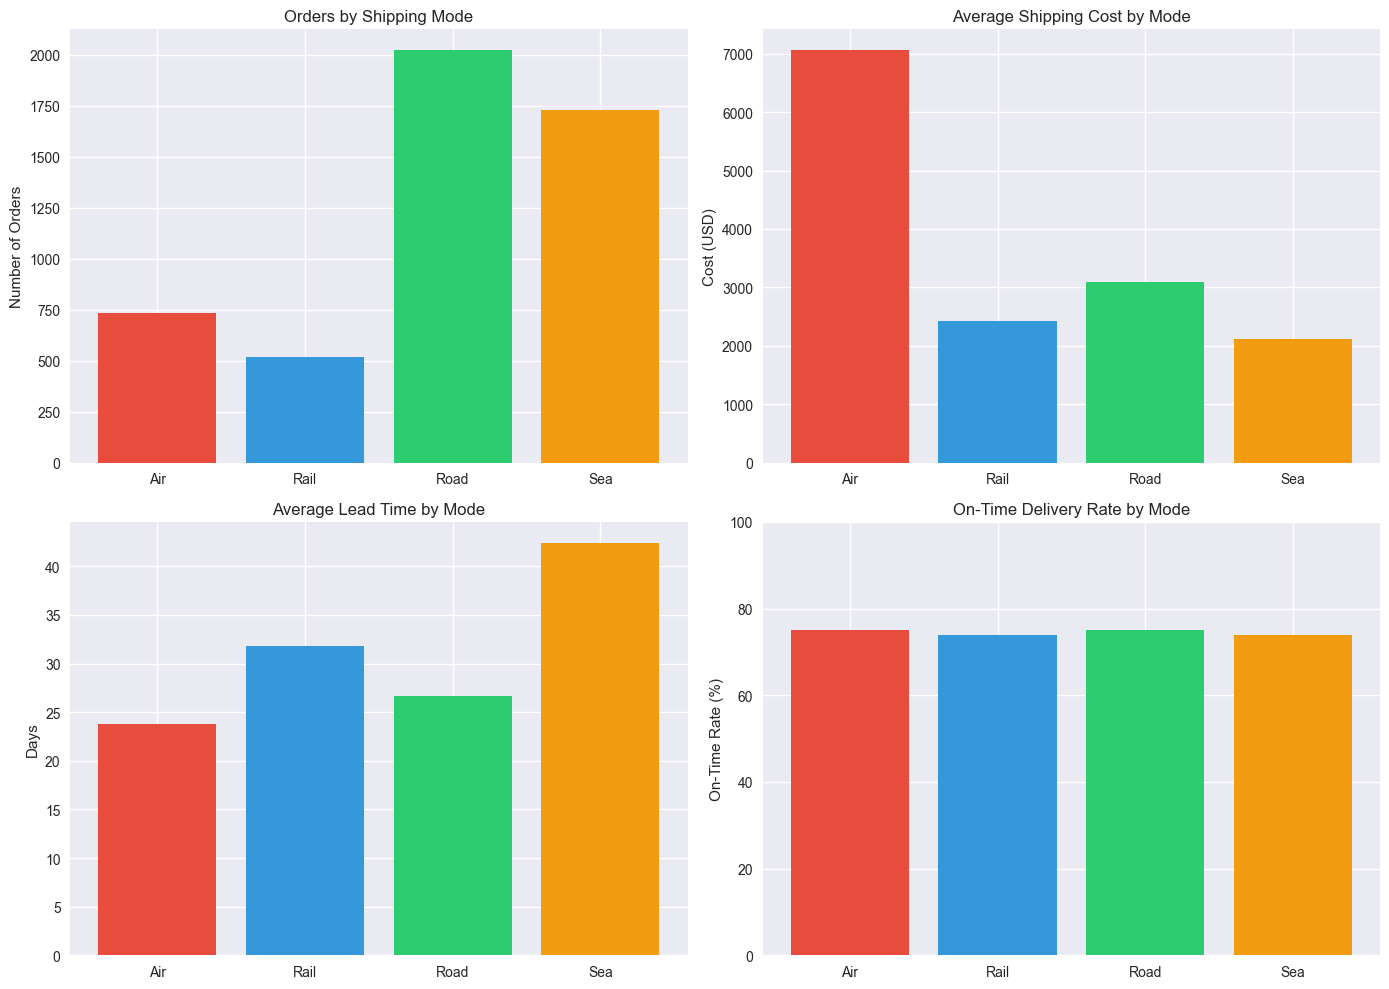

In [14]:
# Shipping mode analysis
shipping_analysis = orders_clean.groupby('Shipping_Mode').agg({
    'Order_ID': 'count',
    'Shipping_Cost': ['mean', 'sum'],
    'Lead_Time_Days': 'mean',
    'On_Time_Delivery': 'mean'
}).round(2)

shipping_analysis.columns = ['Order_Count', 'Avg_Shipping_Cost', 'Total_Shipping_Cost', 
                              'Avg_Lead_Time', 'On_Time_Rate']
shipping_analysis = shipping_analysis.reset_index()

print("Shipping Mode Analysis:")
print(shipping_analysis)

# Visualize shipping metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Order count by shipping mode
axes[0, 0].bar(shipping_analysis['Shipping_Mode'], shipping_analysis['Order_Count'], 
               color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[0, 0].set_title('Orders by Shipping Mode')
axes[0, 0].set_ylabel('Number of Orders')

# Average shipping cost
axes[0, 1].bar(shipping_analysis['Shipping_Mode'], shipping_analysis['Avg_Shipping_Cost'], 
               color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[0, 1].set_title('Average Shipping Cost by Mode')
axes[0, 1].set_ylabel('Cost (USD)')

# Average lead time
axes[1, 0].bar(shipping_analysis['Shipping_Mode'], shipping_analysis['Avg_Lead_Time'], 
               color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[1, 0].set_title('Average Lead Time by Mode')
axes[1, 0].set_ylabel('Days')

# On-time delivery rate
axes[1, 1].bar(shipping_analysis['Shipping_Mode'], shipping_analysis['On_Time_Rate']*100, 
               color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[1, 1].set_title('On-Time Delivery Rate by Mode')
axes[1, 1].set_ylabel('On-Time Rate (%)')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('images/shipping_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 5. Supply Chain KPIs Analysis

### 5.1 Calculate Key Performance Indicators

In [15]:
# Calculate comprehensive KPIs
def calculate_kpis(df):
    """Calculate supply chain KPIs"""
    kpis = {}
    
    # Order Fulfillment KPIs
    total_orders = len(df)
    delivered_orders = len(df[df['Order_Status'] == 'Delivered'])
    kpis['Order_Fulfillment_Rate'] = (delivered_orders / total_orders) * 100
    
    # On-Time Delivery Rate
    on_time_deliveries = df[df['On_Time_Delivery'] == 1]['On_Time_Delivery'].count()
    total_deliveries = df['On_Time_Delivery'].count()
    kpis['On_Time_Delivery_Rate'] = (on_time_deliveries / total_deliveries) * 100 if total_deliveries > 0 else 0
    
    # Average Lead Time
    kpis['Avg_Lead_Time_Days'] = df['Lead_Time_Days'].mean()
    
    # Perfect Order Rate (delivered on time without issues)
    perfect_orders = len(df[(df['Order_Status'] == 'Delivered') & (df['Delay_Days'] == 0)])
    kpis['Perfect_Order_Rate'] = (perfect_orders / total_orders) * 100
    
    # Order Cycle Time
    kpis['Avg_Order_Cycle_Time'] = df['Actual_Lead_Time'].mean()
    
    # Inventory Turnover (simplified)
    total_revenue = df['Total_Amount'].sum()
    avg_inventory = df['Inventory_Level'].mean()
    kpis['Inventory_Turnover_Ratio'] = total_revenue / avg_inventory if avg_inventory > 0 else 0
    
    # Cost Metrics
    kpis['Avg_Order_Value'] = df['Total_Amount'].mean()
    kpis['Avg_Shipping_Cost'] = df['Shipping_Cost'].mean()
    kpis['Shipping_Cost_Ratio'] = (df['Shipping_Cost'].sum() / df['Total_Amount'].sum()) * 100
    
    # Delay Metrics
    delayed_orders = df[df['Delay_Days'] > 0]
    kpis['Delay_Rate'] = (len(delayed_orders) / delivered_orders) * 100 if delivered_orders > 0 else 0
    kpis['Avg_Delay_Days'] = delayed_orders['Delay_Days'].mean() if len(delayed_orders) > 0 else 0
    
    # Cancellation Rate
    cancelled_orders = len(df[df['Order_Status'] == 'Cancelled'])
    kpis['Cancellation_Rate'] = (cancelled_orders / total_orders) * 100
    
    return kpis

# Calculate overall KPIs
overall_kpis = calculate_kpis(orders_clean)

print("=== SUPPLY CHAIN KEY PERFORMANCE INDICATORS ===\n")
for kpi, value in overall_kpis.items():
    if 'Rate' in kpi or 'Ratio' in kpi:
        print(f"{kpi.replace('_', ' ')}: {value:.2f}%")
    elif 'Days' in kpi or 'Time' in kpi:
        print(f"{kpi.replace('_', ' ')}: {value:.2f} days")
    else:
        print(f"{kpi.replace('_', ' ')}: ${value:,.2f}")

=== SUPPLY CHAIN KEY PERFORMANCE INDICATORS ===

Order Fulfillment Rate: 81.32%
On Time Delivery Rate: 74.59%
Avg Lead Time Days: 32.21 days
Perfect Order Rate: 60.66%
Avg Order Cycle Time: 35.62 days
Inventory Turnover Ratio: 24719.15%
Avg Order Value: $12,540.28
Avg Shipping Cost: $3,267.83
Shipping Cost Ratio: 26.06%
Delay Rate: 25.41%
Avg Delay Days: 4.89 days
Cancellation Rate: 4.40%


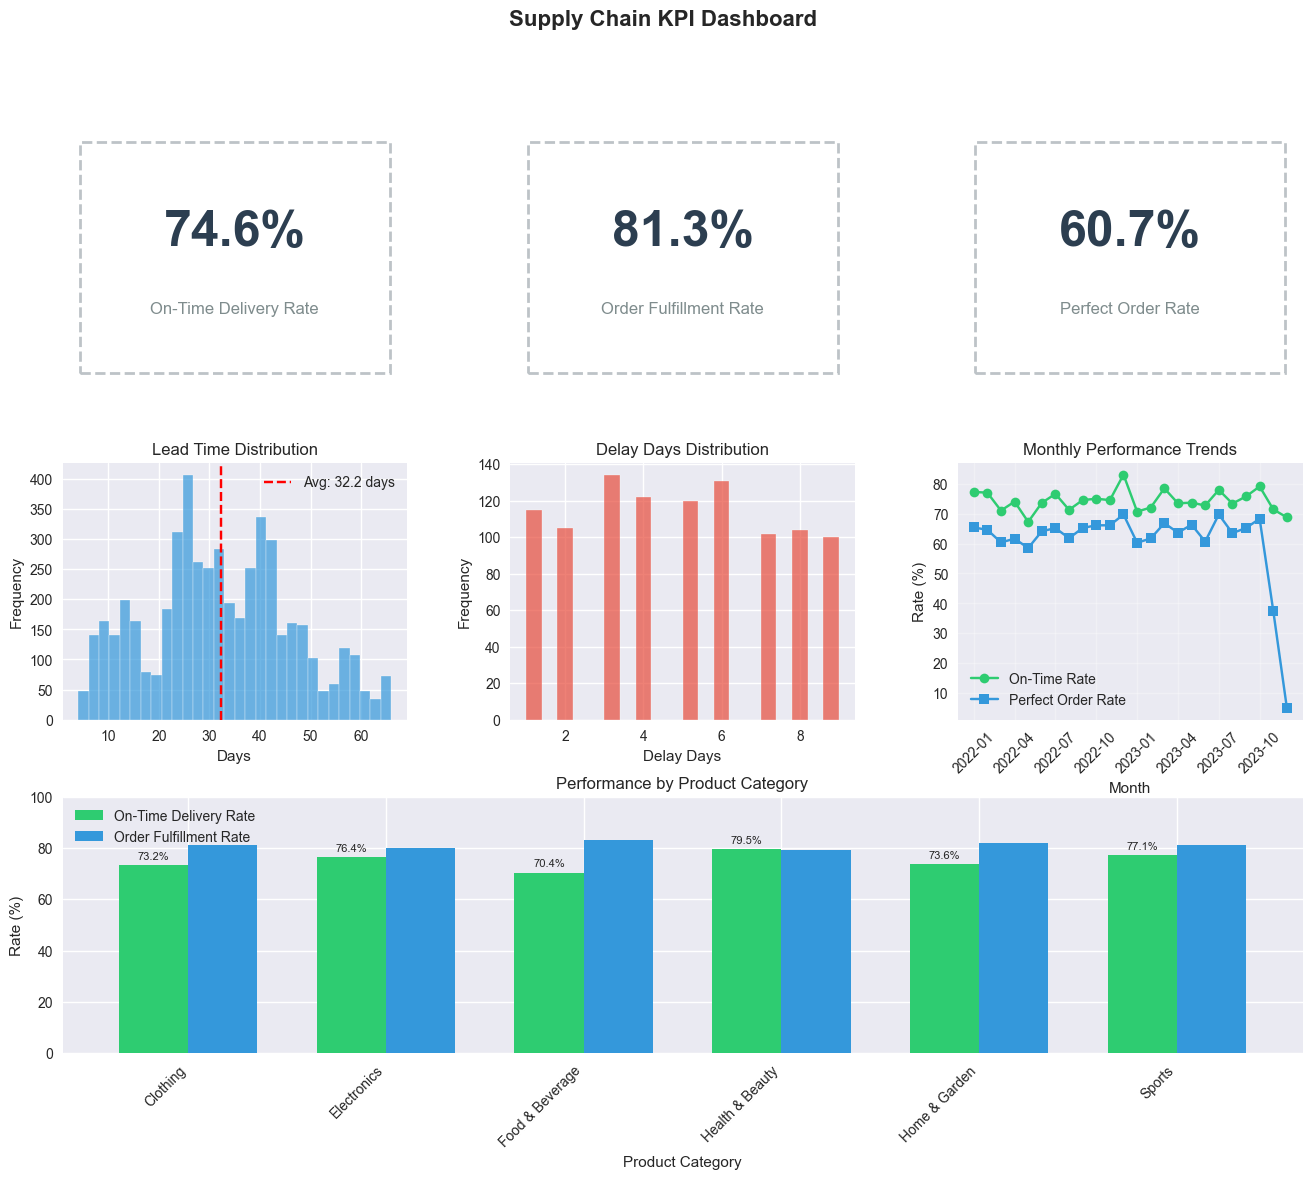

In [16]:
# KPI Dashboard Visualization
fig = plt.figure(figsize=(16, 12))

# Create grid for subplots
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# KPI Cards (top row)
kpi_cards = [
    ('On-Time Delivery Rate', overall_kpis['On_Time_Delivery_Rate'], '%'),
    ('Order Fulfillment Rate', overall_kpis['Order_Fulfillment_Rate'], '%'),
    ('Perfect Order Rate', overall_kpis['Perfect_Order_Rate'], '%')
]

for idx, (name, value, unit) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, idx])
    ax.text(0.5, 0.6, f'{value:.1f}{unit}', ha='center', va='center', 
            fontsize=36, fontweight='bold', color='#2c3e50')
    ax.text(0.5, 0.3, name, ha='center', va='center', 
            fontsize=12, color='#7f8c8d')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, 
                                edgecolor='#bdc3c7', linewidth=2, linestyle='--'))

# Lead Time Distribution
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(orders_clean['Lead_Time_Days'], bins=30, color='#3498db', edgecolor='white', alpha=0.7)
ax1.axvline(overall_kpis['Avg_Lead_Time_Days'], color='red', linestyle='--', 
            label=f"Avg: {overall_kpis['Avg_Lead_Time_Days']:.1f} days")
ax1.set_title('Lead Time Distribution')
ax1.set_xlabel('Days')
ax1.set_ylabel('Frequency')
ax1.legend()

# Delay Analysis
ax2 = fig.add_subplot(gs[1, 1])
delay_data = orders_clean[orders_clean['Delay_Days'] > 0]['Delay_Days']
if len(delay_data) > 0:
    ax2.hist(delay_data, bins=20, color='#e74c3c', edgecolor='white', alpha=0.7)
    ax2.set_title('Delay Days Distribution')
    ax2.set_xlabel('Delay Days')
    ax2.set_ylabel('Frequency')

# Monthly KPI Trend
ax3 = fig.add_subplot(gs[1, 2])
monthly_kpis = orders_clean.groupby('Year_Month').apply(calculate_kpis).apply(pd.Series)
monthly_kpis.index = monthly_kpis.index.astype(str)
ax3.plot(range(len(monthly_kpis)), monthly_kpis['On_Time_Delivery_Rate'], 
         marker='o', label='On-Time Rate', color='#2ecc71')
ax3.plot(range(len(monthly_kpis)), monthly_kpis['Perfect_Order_Rate'], 
         marker='s', label='Perfect Order Rate', color='#3498db')
ax3.set_title('Monthly Performance Trends')
ax3.set_xlabel('Month')
ax3.set_ylabel('Rate (%)')
ax3.set_xticks(range(0, len(monthly_kpis), 3))
ax3.set_xticklabels(monthly_kpis.index[::3], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Category Performance
ax4 = fig.add_subplot(gs[2, :])
category_kpis = orders_clean.groupby('Category').apply(calculate_kpis).apply(pd.Series)
x = np.arange(len(category_kpis))
width = 0.35

bars1 = ax4.bar(x - width/2, category_kpis['On_Time_Delivery_Rate'], width, 
                label='On-Time Delivery Rate', color='#2ecc71')
bars2 = ax4.bar(x + width/2, category_kpis['Order_Fulfillment_Rate'], width, 
                label='Order Fulfillment Rate', color='#3498db')

ax4.set_xlabel('Product Category')
ax4.set_ylabel('Rate (%)')
ax4.set_title('Performance by Product Category')
ax4.set_xticks(x)
ax4.set_xticklabels(category_kpis.index, rotation=45, ha='right')
ax4.legend()
ax4.set_ylim(0, 100)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Supply Chain KPI Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('images/kpi_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 6. Advanced Analytics

### 6.1 Supplier Performance Analysis

In [17]:
# Supplier performance analysis
supplier_performance = orders_clean.groupby('Supplier_ID').agg({
    'Order_ID': 'count',
    'Total_Amount': 'sum',
    'Lead_Time_Days': 'mean',
    'Delay_Days': 'mean',
    'On_Time_Delivery': 'mean',
    'Order_Status': lambda x: (x == 'Delivered').sum()
}).reset_index()

supplier_performance.columns = ['Supplier_ID', 'Order_Count', 'Total_Revenue', 
                                 'Avg_Lead_Time', 'Avg_Delay', 'On_Time_Rate', 'Delivered_Count']

# Merge with supplier info
supplier_performance = supplier_performance.merge(
    suppliers[['Supplier_ID', 'Supplier_Name', 'Country', 'Reliability_Score']], 
    on='Supplier_ID'
)

# Calculate fulfillment rate
supplier_performance['Fulfillment_Rate'] = (supplier_performance['Delivered_Count'] / 
                                             supplier_performance['Order_Count']) * 100
supplier_performance['On_Time_Rate'] = supplier_performance['On_Time_Rate'] * 100

# Sort by performance
supplier_performance = supplier_performance.sort_values('On_Time_Rate', ascending=False)

print("Top 10 Suppliers by On-Time Delivery Rate:")
print(supplier_performance[['Supplier_Name', 'Country', 'Order_Count', 
                            'On_Time_Rate', 'Fulfillment_Rate', 'Avg_Lead_Time']].head(10).round(2))

Top 10 Suppliers by On-Time Delivery Rate:
   Supplier_Name  Country  Order_Count  On_Time_Rate  Fulfillment_Rate  \
14   Supplier_20      USA          581         87.18             80.55   
8     Supplier_9  Vietnam          318         86.69             77.99   
6     Supplier_7  Germany          208         85.54             79.81   
9    Supplier_11    India          191         76.47             80.10   
11   Supplier_16    India          301         74.40             83.06   
4     Supplier_5  Germany          307         73.83             83.39   
3     Supplier_4      USA          207         73.68             82.61   
0     Supplier_1  Germany          422         71.82             78.20   
12   Supplier_17  Vietnam          692         71.28             82.51   
13   Supplier_19  Vietnam          263         70.85             84.79   

    Avg_Lead_Time  
14          29.55  
8           53.52  
6           48.04  
9           46.29  
11          32.08  
4           30.92  
3 

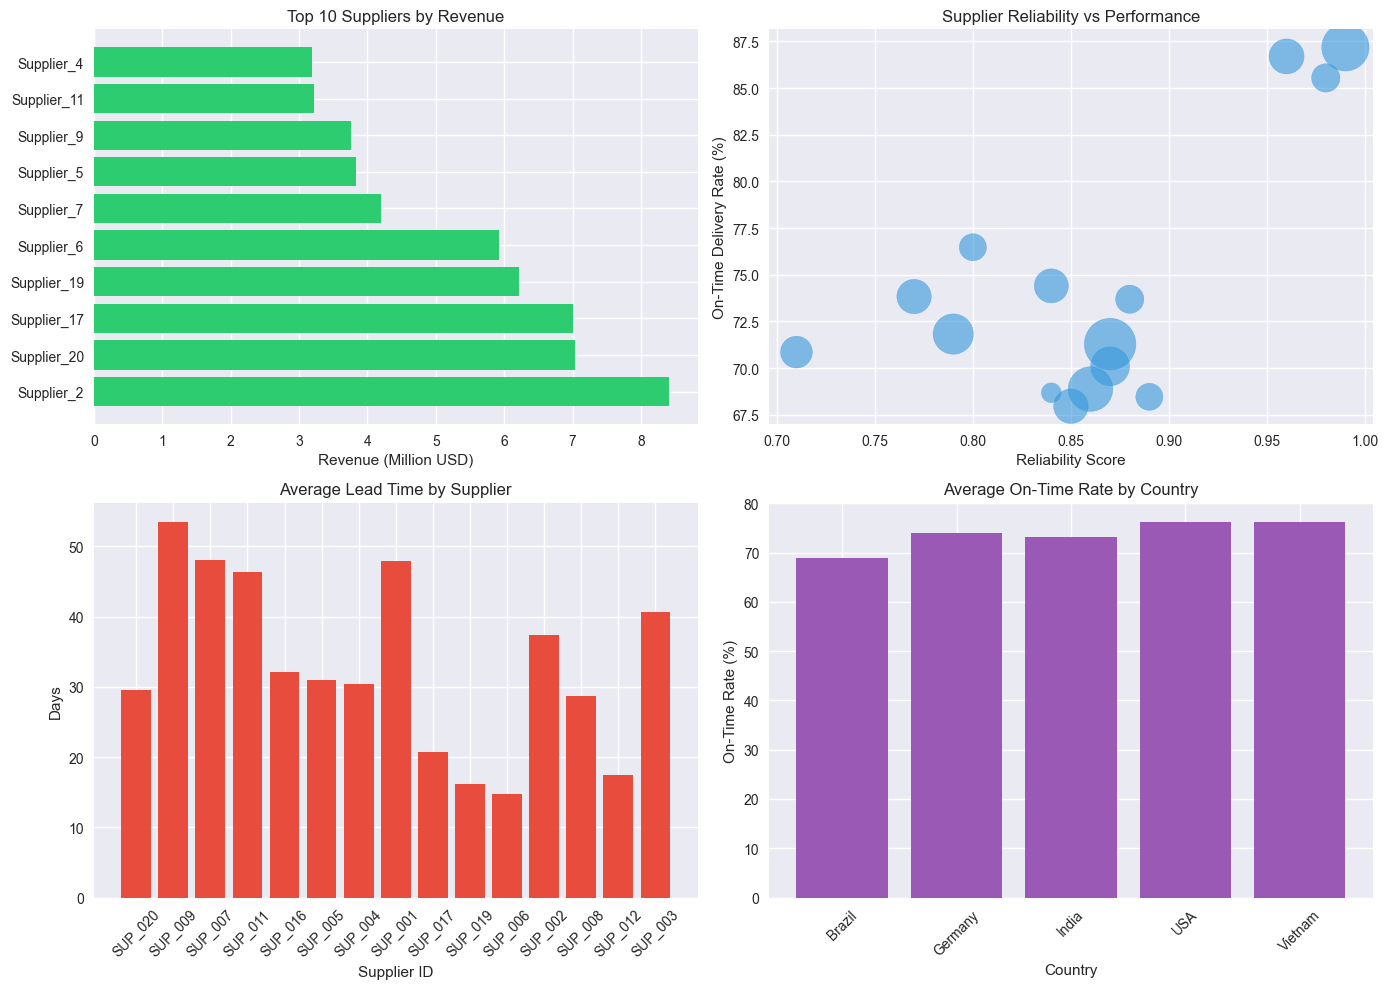

In [18]:
# Supplier performance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top suppliers by revenue
top_revenue = supplier_performance.nlargest(10, 'Total_Revenue')
axes[0, 0].barh(top_revenue['Supplier_Name'], top_revenue['Total_Revenue']/1e6, color='#2ecc71')
axes[0, 0].set_title('Top 10 Suppliers by Revenue')
axes[0, 0].set_xlabel('Revenue (Million USD)')

# On-time rate vs Reliability score
axes[0, 1].scatter(supplier_performance['Reliability_Score'], 
                   supplier_performance['On_Time_Rate'], 
                   s=supplier_performance['Order_Count']*2, 
                   alpha=0.6, color='#3498db')
axes[0, 1].set_xlabel('Reliability Score')
axes[0, 1].set_ylabel('On-Time Delivery Rate (%)')
axes[0, 1].set_title('Supplier Reliability vs Performance')

# Lead time comparison
axes[1, 0].bar(supplier_performance['Supplier_ID'], supplier_performance['Avg_Lead_Time'], 
               color='#e74c3c')
axes[1, 0].set_title('Average Lead Time by Supplier')
axes[1, 0].set_xlabel('Supplier ID')
axes[1, 0].set_ylabel('Days')
axes[1, 0].tick_params(axis='x', rotation=45)

# Performance by country
country_perf = supplier_performance.groupby('Country').agg({
    'On_Time_Rate': 'mean',
    'Order_Count': 'sum'
}).reset_index()
axes[1, 1].bar(country_perf['Country'], country_perf['On_Time_Rate'], color='#9b59b6')
axes[1, 1].set_title('Average On-Time Rate by Country')
axes[1, 1].set_xlabel('Country')
axes[1, 1].set_ylabel('On-Time Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/supplier_performance.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Demand Forecasting

Demand Forecasting Model Performance:
Training MAE: 709.43
Testing MAE: 923.42
Training R²: 0.0144
Testing R²: -0.9321


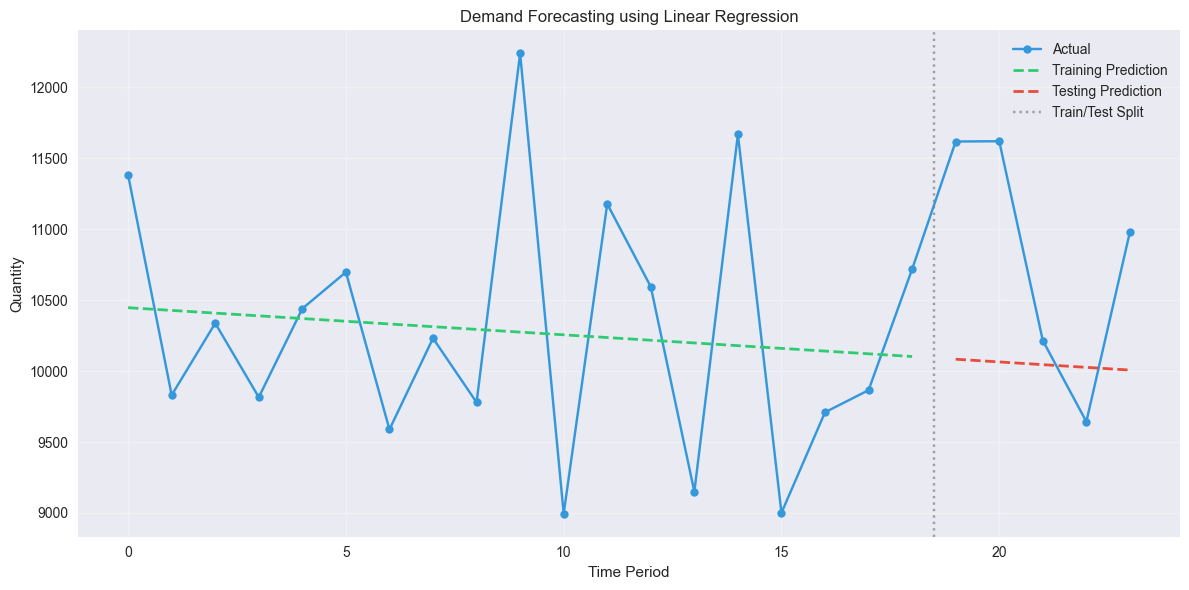

In [19]:
# Prepare data for forecasting
monthly_demand = orders_clean.groupby(['Year', 'Month']).agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).reset_index()

# Create time index
monthly_demand['Time_Index'] = range(len(monthly_demand))

# Split data for training and testing
train_size = int(len(monthly_demand) * 0.8)
train_data = monthly_demand[:train_size]
test_data = monthly_demand[train_size:]

# Train linear regression model
X_train = train_data[['Time_Index']]
y_train = train_data['Quantity']
X_test = test_data[['Time_Index']]
y_test = test_data['Quantity']

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Demand Forecasting Model Performance:")
print(f"Training MAE: {train_mae:.2f}")
print(f"Testing MAE: {test_mae:.2f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")

# Visualize forecast
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual data
ax.plot(monthly_demand['Time_Index'], monthly_demand['Quantity'], 
        'o-', label='Actual', color='#3498db', markersize=6)

# Plot predictions
ax.plot(train_data['Time_Index'], y_pred_train, 
        '--', label='Training Prediction', color='#2ecc71', linewidth=2)
ax.plot(test_data['Time_Index'], y_pred_test, 
        '--', label='Testing Prediction', color='#e74c3c', linewidth=2)

ax.axvline(x=train_size-0.5, color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

ax.set_xlabel('Time Period')
ax.set_ylabel('Quantity')
ax.set_title('Demand Forecasting using Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/demand_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Correlation Analysis

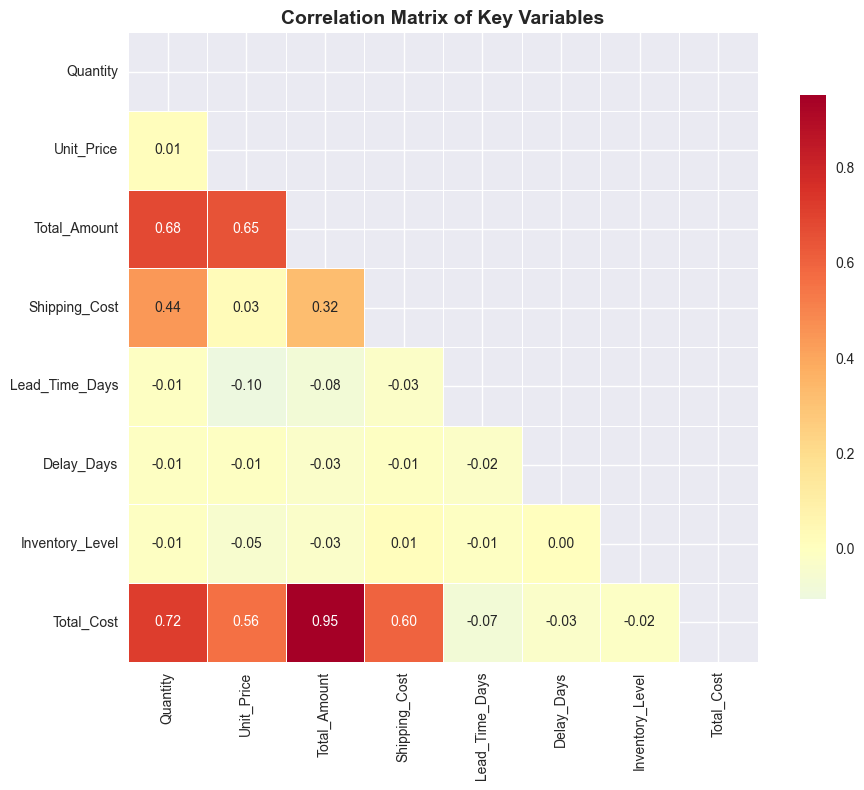


Strongest Correlations:
  Total_Amount ↔ Total_Cost: 0.952
  Quantity ↔ Total_Cost: 0.720
  Quantity ↔ Total_Amount: 0.680
  Unit_Price ↔ Total_Amount: 0.648
  Shipping_Cost ↔ Total_Cost: 0.598


In [20]:
# Correlation analysis
numeric_columns = ['Quantity', 'Unit_Price', 'Total_Amount', 'Shipping_Cost', 
                   'Lead_Time_Days', 'Delay_Days', 'Inventory_Level', 'Total_Cost']

correlation_matrix = orders_clean[numeric_columns].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\nStrongest Correlations:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((
            correlation_matrix.columns[i], 
            correlation_matrix.columns[j], 
            correlation_matrix.iloc[i, j]
        ))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for var1, var2, corr in corr_pairs[:5]:
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

---

## 7. Visualizations & Dashboards

### 7.1 Interactive Dashboard with Plotly

✅ Interactive dashboard saved to: dashboards/interactive_dashboard.html


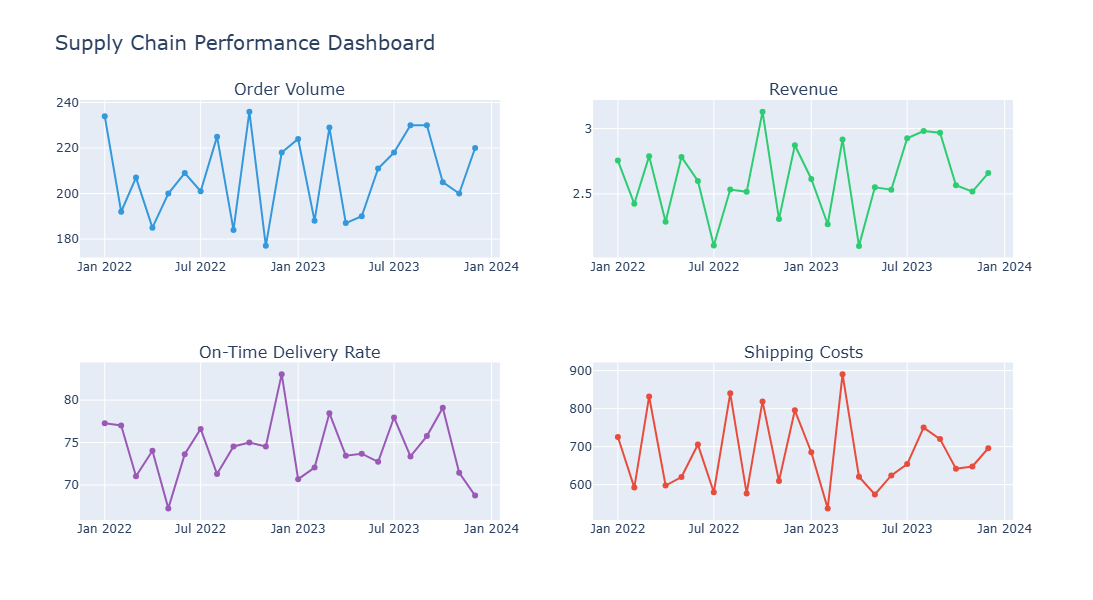

In [21]:
# Create interactive dashboard
# 1. Monthly Performance Dashboard
monthly_metrics = orders_clean.groupby(['Year', 'Month']).agg({
    'Order_ID': 'count',
    'Total_Amount': 'sum',
    'On_Time_Delivery': 'mean',
    'Shipping_Cost': 'sum'
}).reset_index()

monthly_metrics['Date'] = pd.to_datetime(monthly_metrics[['Year', 'Month']].assign(day=1))
monthly_metrics['On_Time_Delivery'] = monthly_metrics['On_Time_Delivery'] * 100

# Create subplot figure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Order Volume', 'Revenue', 'On-Time Delivery Rate', 'Shipping Costs'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Order Volume
fig.add_trace(
    go.Scatter(x=monthly_metrics['Date'], y=monthly_metrics['Order_ID'],
               mode='lines+markers', name='Orders', line=dict(color='#3498db', width=2)),
    row=1, col=1
)

# Revenue
fig.add_trace(
    go.Scatter(x=monthly_metrics['Date'], y=monthly_metrics['Total_Amount']/1e6,
               mode='lines+markers', name='Revenue (M)', line=dict(color='#2ecc71', width=2)),
    row=1, col=2
)

# On-Time Delivery Rate
fig.add_trace(
    go.Scatter(x=monthly_metrics['Date'], y=monthly_metrics['On_Time_Delivery'],
               mode='lines+markers', name='On-Time %', line=dict(color='#9b59b6', width=2)),
    row=2, col=1
)

# Shipping Costs
fig.add_trace(
    go.Scatter(x=monthly_metrics['Date'], y=monthly_metrics['Shipping_Cost']/1e3,
               mode='lines+markers', name='Shipping (K)', line=dict(color='#e74c3c', width=2)),
    row=2, col=2
)

fig.update_layout(
    title_text="Supply Chain Performance Dashboard",
    title_font_size=20,
    height=600,
    showlegend=False
)

fig.write_html("dashboards/interactive_dashboard.html")
print("✅ Interactive dashboard saved to: dashboards/interactive_dashboard.html")
fig.show()

✅ Sunburst chart saved to: dashboards/category_sunburst.html


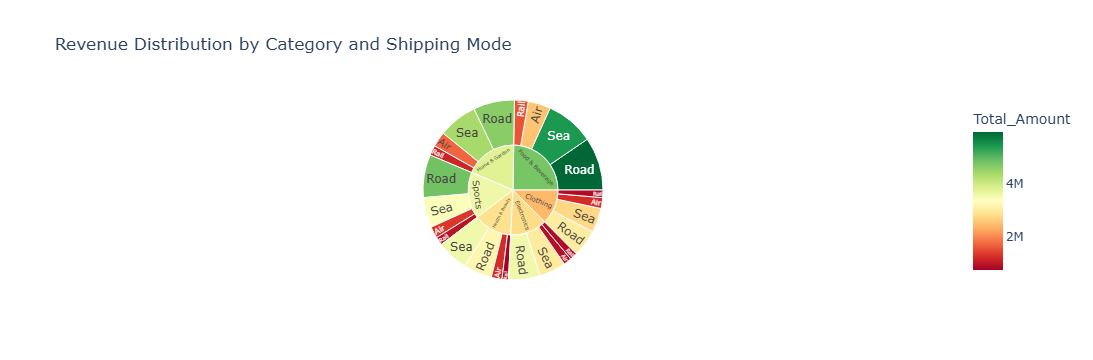

In [22]:
# 2. Category Performance Sunburst Chart
category_metrics = orders_clean.groupby(['Category', 'Shipping_Mode']).agg({
    'Total_Amount': 'sum',
    'Order_ID': 'count'
}).reset_index()

fig = px.sunburst(
    category_metrics,
    path=['Category', 'Shipping_Mode'],
    values='Total_Amount',
    color='Total_Amount',
    color_continuous_scale='RdYlGn',
    title='Revenue Distribution by Category and Shipping Mode'
)

fig.write_html("dashboards/category_sunburst.html")
print("✅ Sunburst chart saved to: dashboards/category_sunburst.html")
fig.show()

✅ Geographic analysis saved to: dashboards/geographic_analysis.html


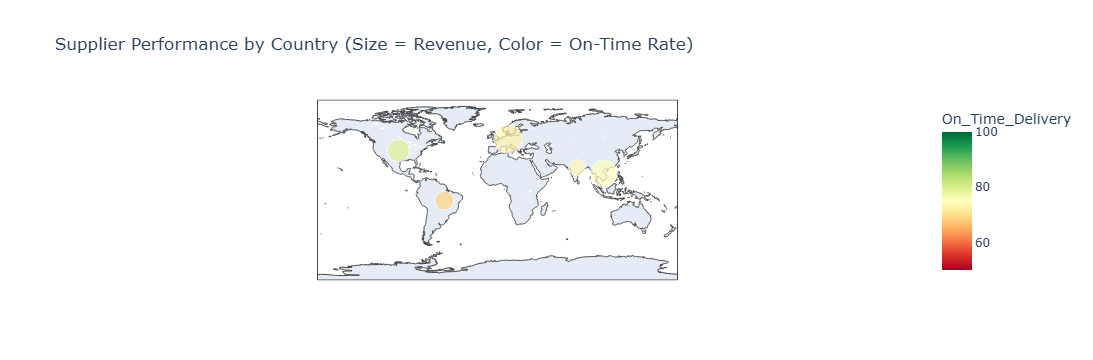

In [23]:
# 3. Geographic Supplier Analysis
country_metrics = orders_clean.groupby('Supplier_Country').agg({
    'Total_Amount': 'sum',
    'Order_ID': 'count',
    'On_Time_Delivery': 'mean',
    'Lead_Time_Days': 'mean'
}).reset_index()

country_metrics['On_Time_Delivery'] = country_metrics['On_Time_Delivery'] * 100

fig = px.scatter_geo(
    country_metrics,
    locations='Supplier_Country',
    locationmode='country names',
    size='Total_Amount',
    color='On_Time_Delivery',
    hover_name='Supplier_Country',
    hover_data=['Order_ID', 'Lead_Time_Days'],
    color_continuous_scale='RdYlGn',
    range_color=[50, 100],
    title='Supplier Performance by Country (Size = Revenue, Color = On-Time Rate)'
)

fig.write_html("dashboards/geographic_analysis.html")
print("✅ Geographic analysis saved to: dashboards/geographic_analysis.html")
fig.show()

---

## 8. Insights & Recommendations

In [24]:
# Generate comprehensive insights
print("="*60)
print("SUPPLY CHAIN ANALYTICS - KEY INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("\n📊 OVERALL PERFORMANCE SUMMARY")
print("-"*40)
print(f"• Total Orders Processed: {len(orders_clean):,}")
print(f"• Total Revenue: ${orders_clean['Total_Amount'].sum()/1e6:.2f} Million")
print(f"• Average Order Value: ${orders_clean['Total_Amount'].mean():.2f}")
print(f"• Order Fulfillment Rate: {overall_kpis['Order_Fulfillment_Rate']:.1f}%")
print(f"• On-Time Delivery Rate: {overall_kpis['On_Time_Delivery_Rate']:.1f}%")
print(f"• Perfect Order Rate: {overall_kpis['Perfect_Order_Rate']:.1f}%")

print("\n🚚 SHIPPING & LOGISTICS INSIGHTS")
print("-"*40)

# Shipping mode insights
best_mode = shipping_analysis.loc[shipping_analysis['On_Time_Rate'].idxmax()]
worst_mode = shipping_analysis.loc[shipping_analysis['On_Time_Rate'].idxmin()]

print(f"• Best Performing Mode: {best_mode['Shipping_Mode']} ({best_mode['On_Time_Rate']*100:.1f}% on-time)")
print(f"• Mode Needing Improvement: {worst_mode['Shipping_Mode']} ({worst_mode['On_Time_Rate']*100:.1f}% on-time)")
print(f"• Average Lead Time: {overall_kpis['Avg_Lead_Time_Days']:.1f} days")
print(f"• Average Delay (when delayed): {overall_kpis['Avg_Delay_Days']:.1f} days")

print("\n🏭 SUPPLIER PERFORMANCE INSIGHTS")
print("-"*40)

top_supplier = supplier_performance.iloc[0]
bottom_supplier = supplier_performance.iloc[-1]

print(f"• Top Supplier: {top_supplier['Supplier_Name']} ({top_supplier['On_Time_Rate']:.1f}% on-time)")
print(f"• Underperforming Supplier: {bottom_supplier['Supplier_Name']} ({bottom_supplier['On_Time_Rate']:.1f}% on-time)")

# Country analysis
best_country = country_perf.loc[country_perf['On_Time_Rate'].idxmax()]
print(f"• Best Performing Country: {best_country['Country']} ({best_country['On_Time_Rate']:.1f}% on-time)")

print("\n📈 TREND ANALYSIS")
print("-"*40)

# Monthly trend analysis
monthly_orders_trend = monthly_orders.copy()
monthly_orders_trend['Order_Trend'] = monthly_orders_trend['Order_ID'].pct_change() * 100
avg_growth = monthly_orders_trend['Order_Trend'].mean()

print(f"• Average Monthly Order Growth: {avg_growth:.2f}%")

# Category performance
best_category = category_kpis.loc[category_kpis['On_Time_Delivery_Rate'].idxmax()]
print(f"• Best Performing Category: {best_category.name} ({best_category['On_Time_Delivery_Rate']:.1f}% on-time)")

print("\n⚠️ AREAS OF CONCERN")
print("-"*40)

if overall_kpis['Delay_Rate'] > 10:
    print(f"• HIGH DELAY RATE: {overall_kpis['Delay_Rate']:.1f}% of orders are delayed")
if overall_kpis['Cancellation_Rate'] > 3:
    print(f"• HIGH CANCELLATION RATE: {overall_kpis['Cancellation_Rate']:.1f}% of orders cancelled")
if overall_kpis['On_Time_Delivery_Rate'] < 85:
    print(f"• LOW ON-TIME DELIVERY: {overall_kpis['On_Time_Delivery_Rate']:.1f}% (Target: >85%)")

# Check low stock situations
low_stock_orders = len(orders_clean[orders_clean['Inventory_Status'] == 'Low Stock'])
if low_stock_orders > 0:
    print(f"• LOW STOCK ISSUES: {low_stock_orders} orders ({low_stock_orders/len(orders_clean)*100:.1f}%) had low inventory")

print("\n💡 RECOMMENDATIONS")
print("-"*40)

print("1. SUPPLIER MANAGEMENT:")
print(f"   → Review contracts with underperforming suppliers")
print(f"   → Implement supplier scorecards with {len(supplier_performance)} key suppliers")
print(f"   → Consider dual-sourcing for critical components")

print("\n2. LOGISTICS OPTIMIZATION:")
print(f"   → Evaluate switching from {worst_mode['Shipping_Mode']} to more reliable modes")
print(f"   → Negotiate better rates with top-performing carriers")
print(f"   → Implement real-time shipment tracking")

print("\n3. INVENTORY MANAGEMENT:")
print(f"   → Review reorder points for products with frequent low stock")
print(f"   → Implement safety stock calculations based on lead time variability")
print(f"   → Consider ABC analysis for inventory prioritization")

print("\n4. PROCESS IMPROVEMENTS:")
print(f"   → Target: Reduce delay rate from {overall_kpis['Delay_Rate']:.1f}% to <10%")
print(f"   → Target: Improve on-time delivery to >90%")
print(f"   → Implement automated alerts for delayed shipments")

print("\n5. TECHNOLOGY ENHANCEMENTS:")
print(f"   → Deploy predictive analytics for demand forecasting")
print(f"   → Integrate supplier portals for better visibility")
print(f"   → Implement dashboard for real-time KPI monitoring")

print("\n" + "="*60)

SUPPLY CHAIN ANALYTICS - KEY INSIGHTS & RECOMMENDATIONS

📊 OVERALL PERFORMANCE SUMMARY
----------------------------------------
• Total Orders Processed: 5,000
• Total Revenue: $62.70 Million
• Average Order Value: $12540.28
• Order Fulfillment Rate: 81.3%
• On-Time Delivery Rate: 74.6%
• Perfect Order Rate: 60.7%

🚚 SHIPPING & LOGISTICS INSIGHTS
----------------------------------------
• Best Performing Mode: Air (75.0% on-time)
• Mode Needing Improvement: Rail (74.0% on-time)
• Average Lead Time: 32.2 days
• Average Delay (when delayed): 4.9 days

🏭 SUPPLIER PERFORMANCE INSIGHTS
----------------------------------------
• Top Supplier: Supplier_20 (87.2% on-time)
• Underperforming Supplier: Supplier_3 (68.0% on-time)
• Best Performing Country: Vietnam (76.3% on-time)

📈 TREND ANALYSIS
----------------------------------------
• Average Monthly Order Growth: 0.72%
• Best Performing Category: Health & Beauty (79.5% on-time)

⚠️ AREAS OF CONCERN
----------------------------------------
• 

---

## Export Summary Report

In [25]:
# Create summary report DataFrame
summary_report = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Total Revenue (M USD)',
        'Average Order Value (USD)',
        'Order Fulfillment Rate (%)',
        'On-Time Delivery Rate (%)',
        'Perfect Order Rate (%)',
        'Average Lead Time (days)',
        'Delay Rate (%)',
        'Cancellation Rate (%)',
        'Average Shipping Cost (USD)',
        'Shipping Cost Ratio (%)',
        'Inventory Turnover Ratio'
    ],
    'Value': [
        f"{len(orders_clean):,}",
        f"{orders_clean['Total_Amount'].sum()/1e6:.2f}",
        f"{orders_clean['Total_Amount'].mean():.2f}",
        f"{overall_kpis['Order_Fulfillment_Rate']:.2f}",
        f"{overall_kpis['On_Time_Delivery_Rate']:.2f}",
        f"{overall_kpis['Perfect_Order_Rate']:.2f}",
        f"{overall_kpis['Avg_Lead_Time_Days']:.2f}",
        f"{overall_kpis['Delay_Rate']:.2f}",
        f"{overall_kpis['Cancellation_Rate']:.2f}",
        f"{overall_kpis['Avg_Shipping_Cost']:.2f}",
        f"{overall_kpis['Shipping_Cost_Ratio']:.2f}",
        f"{overall_kpis['Inventory_Turnover_Ratio']:.2f}"
    ]
})

# Save to CSV
summary_report.to_csv('data/kpi_summary_report.csv', index=False)
print("✅ Summary report saved to: data/kpi_summary_report.csv")
print("\nSummary Report:")
print(summary_report.to_string(index=False))

✅ Summary report saved to: data/kpi_summary_report.csv

Summary Report:
                     Metric    Value
               Total Orders    5,000
      Total Revenue (M USD)    62.70
  Average Order Value (USD) 12540.28
 Order Fulfillment Rate (%)    81.32
  On-Time Delivery Rate (%)    74.59
     Perfect Order Rate (%)    60.66
   Average Lead Time (days)    32.21
             Delay Rate (%)    25.41
      Cancellation Rate (%)     4.40
Average Shipping Cost (USD)  3267.83
    Shipping Cost Ratio (%)    26.06
   Inventory Turnover Ratio 24719.15


---

## Project Completion Summary

### Files Generated:

**Data Files:**
- `data/world_bank_logistics_data.csv` - Real-world logistics data from World Bank
- `data/orders.csv` - 5,000 supply chain order records
- `data/products.csv` - Product master data
- `data/suppliers.csv` - Supplier master data
- `data/warehouses.csv` - Warehouse master data
- `data/customers.csv` - Customer master data
- `data/kpi_summary_report.csv` - KPI summary report

**Visualization Files:**
- `images/logistics_performance_comparison.png`
- `images/trade_statistics.png`
- `images/order_trends.png`
- `images/order_distributions.png`
- `images/shipping_analysis.png`
- `images/kpi_dashboard.png`
- `images/supplier_performance.png`
- `images/demand_forecast.png`
- `images/correlation_matrix.png`

**Interactive Dashboards:**
- `dashboards/interactive_dashboard.html` - Main performance dashboard
- `dashboards/category_sunburst.html` - Category performance visualization
- `dashboards/geographic_analysis.html` - Geographic supplier analysis

### Next Steps for GitHub Documentation:

1. **Create a README.md** with project overview and instructions
2. **Add requirements.txt** listing all dependencies
3. **Include the Jupyter notebook** with all analysis
4. **Upload visualizations** to showcase results
5. **Document insights** in a separate markdown file

---

**Project Completed Successfully! ✅**